# Millikan Oil-Drop Experiment
### Determination of the elementary charge

*Modern Physics Laboratory - Physics Teaching degree, CCENS-UFES.*

Charged oil droplets rise and fall between capacitor plates; timing that motion yields each droplet's radius and charge (with full error propagation). Sorting the charges reveals their quantization into integer multiples of the elementary charge.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # make the physexp package importable
from physexp import millikan, plots
from physexp.display import uframe, apply_style
apply_style()

## 1. Raw measurements

Droplet timings and applied voltages, loaded from `data/millikan_droplets.csv`.

In [2]:
raw = millikan.load_measurements()
raw

,droplet,grid_divisions,voltage_V,rise_time_s,descent_time_s
0,1,30,300,5.903,3.668
1,2,30,300,4.268,2.668
2,3,30,300,3.602,2.633
3,4,30,300,4.603,2.935
4,5,30,300,3.970,2.635
5,6,60,400,7.372,4.535
6,7,60,400,4.769,3.668
7,8,60,400,4.570,5.837
8,9,60,400,5.603,4.770
9,10,60,400,7.603,5.804


## 2. Derived quantities

Speeds, Stokes radius and charge for every droplet, each carrying its propagated uncertainty.

In [3]:
result = millikan.run()
uframe(
    {
        'rise_speed_m_s': result.table['rise_speed_m_s'],
        'fall_speed_m_s': result.table['fall_speed_m_s'],
        'radius_m': result.table['radius_m'],
        'charge_C': result.table['charge_C'],
    },
    droplet=result.table['droplet'],
    voltage_V=result.table['voltage_V'],
)

,rise_speed_m_s,fall_speed_m_s,radius_m,charge_C,droplet,voltage_V
0,0.0001508+/-0.0000017,0.0002426+/-0.0000027,(6.112+/-0.034)e-07,(3.437+/-0.083)e-19,1,300
1,0.0002085+/-0.0000023,0.0003336+/-0.0000038,(7.131+/-0.040)e-07,(5.53+/-0.13)e-19,2,300
2,0.0002471+/-0.0000028,0.0003380+/-0.0000038,(6.081+/-0.035)e-07,(5.09+/-0.12)e-19,3,300
3,0.0001934+/-0.0000022,0.0003032+/-0.0000034,(6.684+/-0.038)e-07,(4.74+/-0.11)e-19,4,300
4,0.0002242+/-0.0000025,0.0003378+/-0.0000038,(6.796+/-0.038)e-07,(5.46+/-0.13)e-19,5,300
5,0.0002415+/-0.0000027,0.0003925+/-0.0000044,(7.837+/-0.044)e-07,(5.33+/-0.11)e-19,6,400
6,0.0003732+/-0.0000042,0.0004853+/-0.0000055,(6.749+/-0.038)e-07,(6.21+/-0.13)e-19,7,400
7,0.0003895+/-0.0000044,0.0003050+/-0.0000034,(5.863+/-0.033)e-07,(4.365+/-0.093)e-19,8,400
8,0.0003177+/-0.0000036,0.0003732+/-0.0000042,(4.750+/-0.027)e-07,(3.518+/-0.075)e-19,9,400
9,0.0002341+/-0.0000026,0.0003067+/-0.0000034,(5.432+/-0.031)e-07,(3.149+/-0.067)e-19,10,400


## 3. Charge quantization

The sorted charges cluster into plateaus; consecutive plateau spacings estimate the elementary charge `e`.

In [4]:
uframe({'charge_C': result.charge_levels['charge_C']}, level=result.charge_levels['level'])

,charge_C,level
0,(2.986+/-0.054)e-19,L1
1,(3.474+/-0.064)e-19,L2
2,(4.555+/-0.086)e-19,L3
3,(5.397+/-0.097)e-19,L4
4,(6.25+/-0.12)e-19,L5


In [5]:
print('Estimated elementary charge  e = {:.2u} C'.format(result.elementary_charge))
print('Literature value             e = 1.602e-19 C')

Estimated elementary charge  e = (1.250+/-0.024)e-19 C
Literature value             e = 1.602e-19 C


## 4. Figures

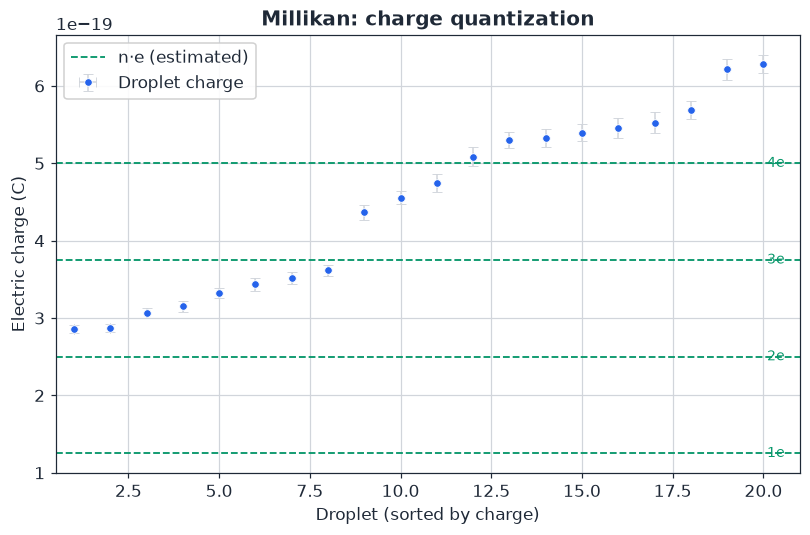

In [6]:
plots.millikan_charge_quantization(result);

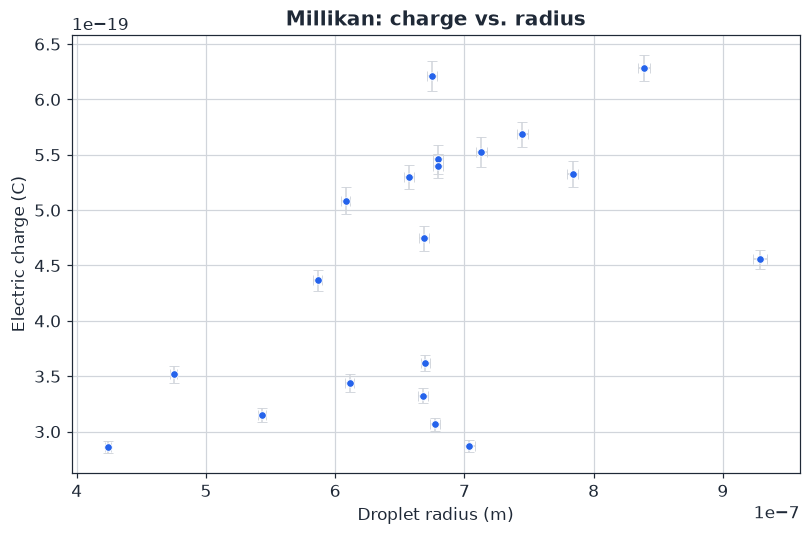

In [7]:
plots.millikan_charge_vs_radius(result);